## Load Data 

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np


df = pd.read_csv('../data/raw/AmesHousing.csv')

df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [2]:
df_copy = df.copy()

select best features for determining how it will affext the house price 

> total actual house area 

- Total_SF = Gr Liv Area + Total Bsmt SF + Garage Area

> total actual house age 

- House_Age = Yr Sold - Year Built

> remodeled house 
- Was_Remodeled = 0 ot 1 in specific year 

In [3]:
print(df[['Gr Liv Area', 'Total Bsmt SF', 'Garage Area', 
          'Lot Area', 'Year Built', 'SalePrice']].describe())

       Gr Liv Area  Total Bsmt SF  Garage Area       Lot Area   Year Built  \
count  2930.000000    2929.000000  2929.000000    2930.000000  2930.000000   
mean   1499.690444    1051.614544   472.819734   10147.921843  1971.356314   
std     505.508887     440.615067   215.046549    7880.017759    30.245361   
min     334.000000       0.000000     0.000000    1300.000000  1872.000000   
25%    1126.000000     793.000000   320.000000    7440.250000  1954.000000   
50%    1442.000000     990.000000   480.000000    9436.500000  1973.000000   
75%    1742.750000    1302.000000   576.000000   11555.250000  2001.000000   
max    5642.000000    6110.000000  1488.000000  215245.000000  2010.000000   

           SalePrice  
count    2930.000000  
mean   180796.060068  
std     79886.692357  
min     12789.000000  
25%    129500.000000  
50%    160000.000000  
75%    213500.000000  
max    755000.000000  


### check houses distributions 

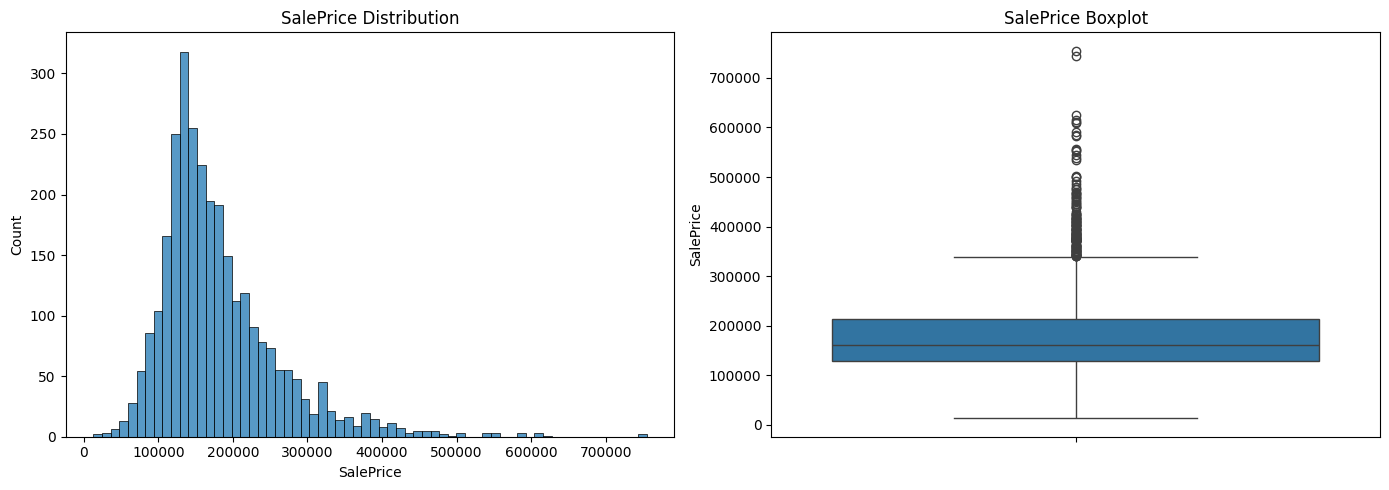

In [4]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['SalePrice'], ax=axes[0])
axes[0].set_title('SalePrice Distribution')

sns.boxplot(df['SalePrice'], ax=axes[1])
axes[1].set_title('SalePrice Boxplot')

plt.tight_layout()
plt.show()

- right skewed 
- over 400k may be outliers 


> apply logg transform to see the results  on ``` df_copy ```

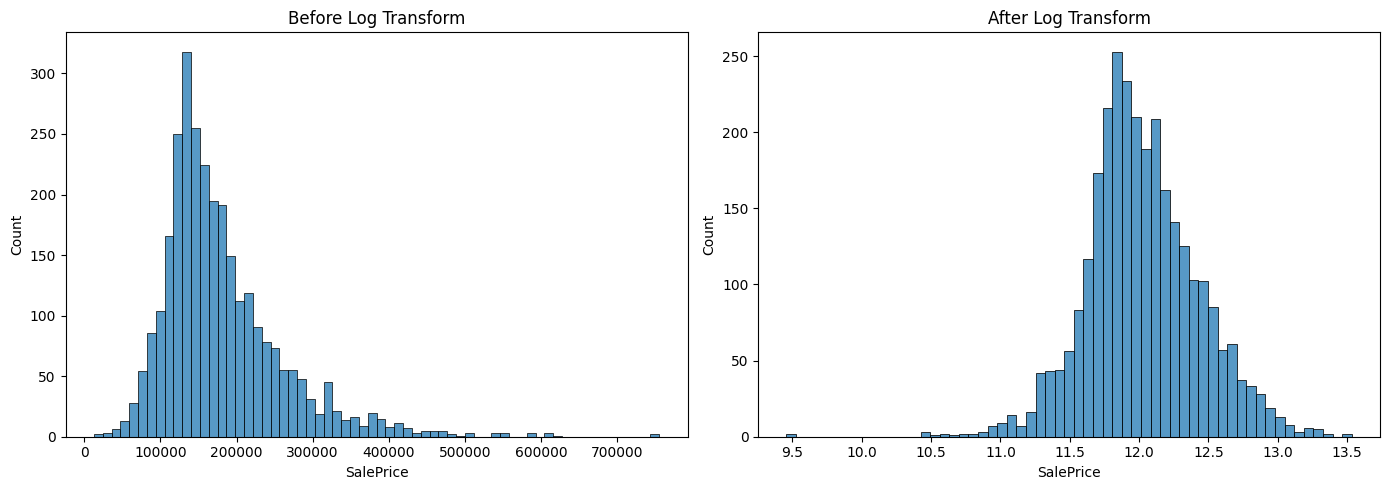

In [5]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_copy['SalePrice'], ax=axes[0])
axes[0].set_title('Before Log Transform')

sns.histplot(np.log1p(df_copy['SalePrice']), ax=axes[1])
axes[1].set_title('After Log Transform')

plt.tight_layout()
plt.show()

Now it is normally distributed !! 

### let's check missing values 

In [6]:
missing = df_copy.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)
print(f"\nTotal columns with missing values: {len(missing)}")

Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
Fireplace Qu      1422
Lot Frontage       490
Garage Cond        159
Garage Qual        159
Garage Finish      159
Garage Yr Blt      159
Garage Type        157
Bsmt Exposure       83
BsmtFin Type 2      81
Bsmt Cond           80
Bsmt Qual           80
BsmtFin Type 1      80
Mas Vnr Area        23
Bsmt Half Bath       2
Bsmt Full Bath       2
BsmtFin SF 1         1
Garage Cars          1
Garage Area          1
Total Bsmt SF        1
Bsmt Unf SF          1
BsmtFin SF 2         1
Electrical           1
dtype: int64

Total columns with missing values: 27


looks like ``` POOL QC ``` has 99% missing values 
- we may remove this columns but it will prevent model from learning that it has pool or not so we should label missing values with ``None``

`` Lot Frontage `` is the distance between the house and the street in feet 
- `` Lot Frontage `` = 70 means the distance between house and street = 70 feet
- **assumption** missing values in `` LOT frontage `` means that the hous may not on the street  

In [7]:
df_copy["Alley"].unique()

array([nan, 'Pave', 'Grvl'], dtype=object)

- Ex = Excellent
- Gd = Good
- TA = Typical/Average
- Fa = Fair
- NaN = no alley

In [8]:
df_copy["Fence"].unique()

array([nan, 'MnPrv', 'GdPrv', 'GdWo', 'MnWw'], dtype=object)

- GdPrv = Good Privacy
- MnPrv = Minimum Privacy
- GdWo = Good Wood
- MnWw = Minimum Wood
- NaN = no fence

In [9]:
df_copy["Pool QC"].unique()

array([nan, 'Ex', 'Gd', 'TA', 'Fa'], dtype=object)

- Ex = Excellent
- Gd = Good
- TA = Typical/Average
- Fa = Fair
- NaN

In [10]:
# replace NaN with None in categorical features 
none_categorical = [
    'Pool QC', 'Misc Feature', 'Alley', 'Fence', 
    'Fireplace Qu', 'Garage Type', 'Garage Finish',
    'Garage Qual', 'Garage Cond', 'Bsmt Qual', 
    'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1',
    'BsmtFin Type 2', 'Mas Vnr Type'
]
# replace NaN with 0 in numerical features 
zero_numerical = [
    'Lot Frontage', 'Garage Yr Blt', 'Mas Vnr Area',
    'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF',
    'Total Bsmt SF', 'Bsmt Full Bath', 'Bsmt Half Bath',
    'Garage Cars', 'Garage Area'
]

mode_cols = ['Electrical']


df_copy[none_categorical] = df_copy[none_categorical].fillna("None")
df_copy[zero_numerical] = df_copy[zero_numerical].fillna(0)
df_copy['Electrical'] = df_copy['Electrical'].fillna(df_copy['Electrical'].mode()[0])


print(df_copy.isnull().sum().sum())

0


replacement Done successfully !!

### Bathroom feature 

- Full Bath , Half Bath , Bsmt Full Bath ,Bsmt Half Bath

- ``Total_Bathrooms`` = Full Bath + Bsmt Full Bath + 0.5 × Half Bath + 0.5 × Bsmt Half Bath

> Bathrooms:
- Full Bath = حمام كامل فيه كل حاجة، دش وتواليت وحوض.
- Half Bath = حمام ناقص، تواليت بس من غير دش.
- Bsmt Full Bath = حمام كامل في البدروم.
- Bsmt Half Bath = حمام ناقص في البدروم.

>Porch:
- Wood Deck SF = تراس خشب برا البيت بالقدم المربع.
- Open Porch SF = برندة مفتوحة.
- Enclosed Porch = برندة مغلقة.
- Screen Porch = برندة بشبك.

- Total_SF = مساحة المعيشة + البدروم + الجراج، ده إجمالي مساحة البيت كله.
- Total_Porch_SF = جمع كل أنواع الـ porch، عشان المساحة الخارجية مهمة.

- Total_Bathrooms = Full Bath + Bsmt Full Bath + نص Half Bath + نص Bsmt Half Bath.

- House_Age = سنة البيع - سنة البناء، ده عمر البيت الفعلي.
- Remod_Age = سنة البيع - سنة التجديد، لو اتجدد قريب هيكون أغلى.
- Was_Remodeled = 1 لو اتجدد، 0 لو لأ.

>Quality
- Total_Quality = Overall Qual + Overall Cond، ده بيجمع الجودة والحالة مع بعض.


> Boolean features:
Has_Pool = 1 لو في pool، 0 لو لأ.
Has_Garage = 1 لو في garage، 0 لو لأ.
Has_Fireplace = 1 لو في fireplace، 0 لو لأ.

In [11]:
def create_features(df):
    df['Total_SF'] = df['Gr Liv Area'] + df['Total Bsmt SF'] + df['Garage Area']
    df['Total_Porch_SF'] = df['Wood Deck SF'] + df['Open Porch SF'] + df['Enclosed Porch'] + df['Screen Porch']
    
    # Bath
    df['Total_Bathrooms'] = (df['Full Bath'] + df['Bsmt Full Bath'] + 
                             0.5 * df['Half Bath'] + 0.5 * df['Bsmt Half Bath'])
    
    # Age
    df['House_Age'] = df['Yr Sold'] - df['Year Built']
    df['Remod_Age'] = df['Yr Sold'] - df['Year Remod/Add']
    df['Was_Remodeled'] = (df['Year Remod/Add'] != df['Year Built']).astype(int)
    
    # Quality
    df['Total_Quality'] = df['Overall Qual'] + df['Overall Cond']
    
    # Boolean
    df['Has_Pool'] = (df['Pool Area'] > 0).astype(int)
    df['Has_Garage'] = (df['Garage Area'] > 0).astype(int)
    df['Has_Fireplace'] = (df['Fireplaces'] > 0).astype(int)
    
    return df



df_featured = create_features(df_copy)


new_features = ['Total_SF', 'Total_Porch_SF', 'Total_Bathrooms', 
                'House_Age', 'Was_Remodeled', 'Total_Quality',
                'Has_Pool', 'Has_Garage', 'Has_Fireplace']

print(df_featured[new_features].describe())



           Total_SF  Total_Porch_SF  Total_Bathrooms    House_Age  \
count   2930.000000     2930.000000      2930.000000  2930.000000   
mean    3023.604437      180.298976         2.217918    36.434130   
std      944.557707      158.621029         0.807444    30.291357   
min      334.000000        0.000000         1.000000    -1.000000   
25%     2372.000000       48.000000         1.500000     7.000000   
50%     2913.500000      163.000000         2.000000    34.000000   
75%     3544.250000      264.000000         2.500000    54.000000   
max    13170.000000     1424.000000         7.000000   136.000000   

       Was_Remodeled  Total_Quality     Has_Pool   Has_Garage  Has_Fireplace  
count    2930.000000    2930.000000  2930.000000  2930.000000    2930.000000  
mean        0.464505      11.658020     0.004437     0.946075       0.514676  
std         0.498824       1.711462     0.066473     0.225908       0.499870  
min         0.000000       2.000000     0.000000     0.000000 

Done !!

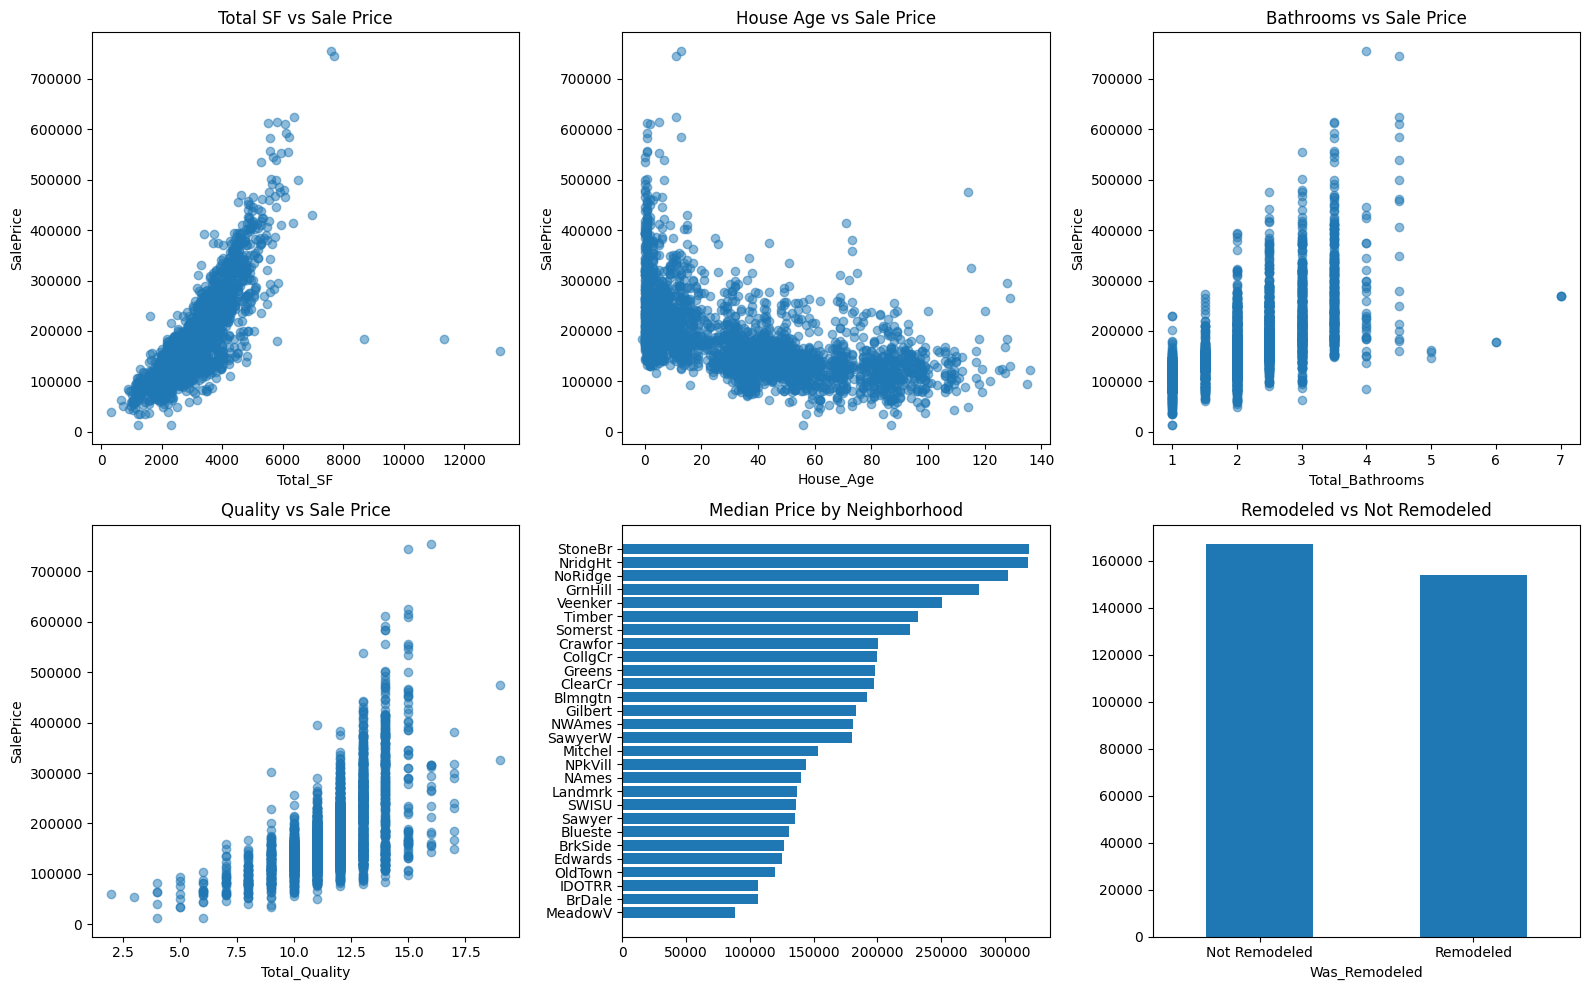

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Total_SF vs SalePrice
axes[0,0].scatter(df_featured['Total_SF'], df_featured['SalePrice'], alpha=0.5)
axes[0,0].set_xlabel('Total_SF')
axes[0,0].set_ylabel('SalePrice')
axes[0,0].set_title('Total SF vs Sale Price')

# 2. House_Age vs SalePrice
axes[0,1].scatter(df_featured['House_Age'], df_featured['SalePrice'], alpha=0.5)
axes[0,1].set_xlabel('House_Age')
axes[0,1].set_ylabel('SalePrice')
axes[0,1].set_title('House Age vs Sale Price')

# 3. Total_Bathrooms vs SalePrice
axes[0,2].scatter(df_featured['Total_Bathrooms'], df_featured['SalePrice'], alpha=0.5)
axes[0,2].set_xlabel('Total_Bathrooms')
axes[0,2].set_ylabel('SalePrice')
axes[0,2].set_title('Bathrooms vs Sale Price')

# 4. Total_Quality vs SalePrice
axes[1,0].scatter(df_featured['Total_Quality'], df_featured['SalePrice'], alpha=0.5)
axes[1,0].set_xlabel('Total_Quality')
axes[1,0].set_ylabel('SalePrice')
axes[1,0].set_title('Quality vs Sale Price')

# 5. Neighborhood vs SalePrice
neighbor_price = df_featured.groupby('Neighborhood')['SalePrice'].median().sort_values()
axes[1,1].barh(neighbor_price.index, neighbor_price.values)
axes[1,1].set_title('Median Price by Neighborhood')

# 6. Was_Remodeled vs SalePrice
df_featured.groupby('Was_Remodeled')['SalePrice'].median().plot(kind='bar', ax=axes[1,2])
axes[1,2].set_title('Remodeled vs Not Remodeled')
axes[1,2].set_xticklabels(['Not Remodeled', 'Remodeled'], rotation=0)

plt.tight_layout()
plt.show()

In [13]:
correlations = df_featured[new_features + ['SalePrice']].corr()['SalePrice'].sort_values(ascending=False)
print(correlations)

SalePrice          1.000000
Total_SF           0.819387
Total_Bathrooms    0.636175
Total_Quality      0.592908
Has_Fireplace      0.481446
Total_Porch_SF     0.381332
Has_Garage         0.225840
Has_Pool           0.087960
Was_Remodeled     -0.047274
House_Age         -0.558907
Name: SalePrice, dtype: float64


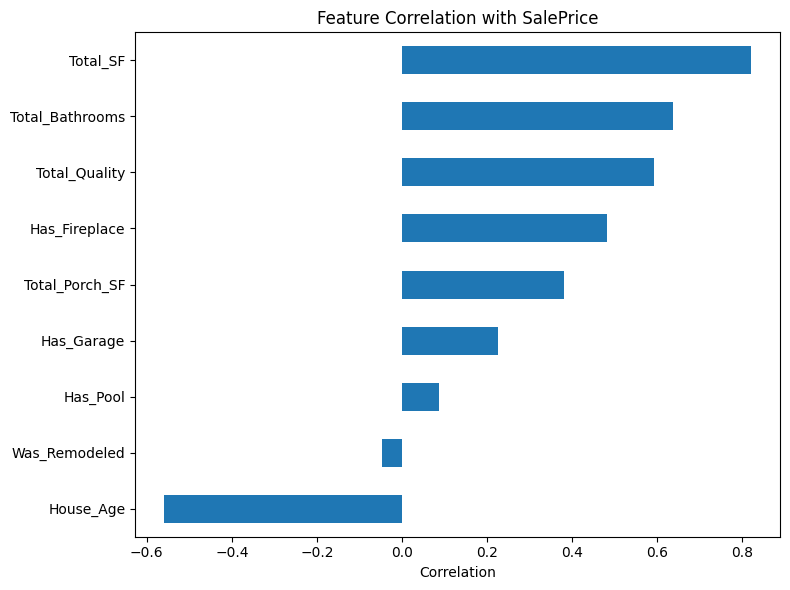

In [14]:

correlations = df_featured[new_features + ['SalePrice']].corr()['SalePrice'].drop('SalePrice').sort_values()

plt.figure(figsize=(8, 6))
correlations.plot(kind='barh')
plt.title('Feature Correlation with SalePrice')
plt.xlabel('Correlation')
plt.tight_layout()
plt.show()

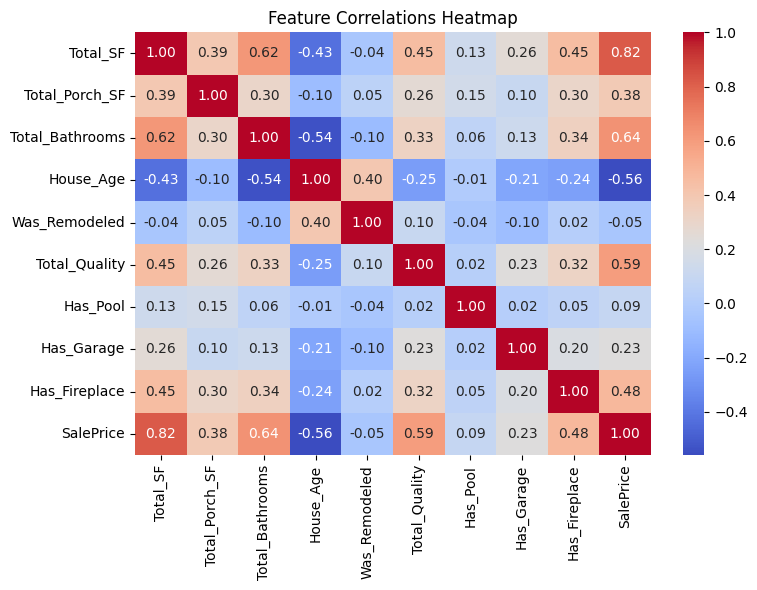

In [15]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    df_featured[new_features + ['SalePrice']].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)
plt.title('Feature Correlations Heatmap')
plt.tight_layout()
plt.show()

## Encoding Part

> first select feature type ( nominal - ordinal )

- Exter Qual :Fa, TA, Gd, Ex
- Sale Type : WD, New, COD
- Street : Pave, Grvl

> Nominal: Neighborhood و Garage Type، -> One Hot Encoding.

> Ordinal: ordering -> Pool QC  [ Fa و TA و Gd و Ex،]  -> Label Encoding or Ordinal Encoding.


In [16]:
df_featured = create_features(df_copy)

## Encoding

In [17]:
ordinal_map = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
ordinal_cols = ['Exter Qual', 'Exter Cond', 'Bsmt Qual', 'Bsmt Cond',
                'Heating QC', 'Kitchen Qual', 'Garage Qual', 
                'Garage Cond', 'Pool QC', 'Fireplace Qu']


for col in ordinal_cols:
    df_featured[col] = df_featured[col].map(ordinal_map)

nominal_cols = df_featured.select_dtypes(include='object').columns.tolist()
df_encoded = pd.get_dummies(df_featured, columns=nominal_cols)


print(f"Shape: {df_encoded.shape}")
print(f"NaN values: {df_encoded.isnull().sum().sum()}")

Shape: (2930, 287)
NaN values: 0


In [18]:
nominal_cols = df_featured.select_dtypes(include='object').columns.tolist()
print(f"Encoding {len(nominal_cols)} columns: {nominal_cols}")

df_encoded = pd.get_dummies(df_featured, columns=nominal_cols)
print(f"After encoding: {df_encoded.shape}")

Encoding 33 columns: ['MS Zoning', 'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type', 'House Style', 'Roof Style', 'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Foundation', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2', 'Heating', 'Central Air', 'Electrical', 'Functional', 'Garage Type', 'Garage Finish', 'Paved Drive', 'Fence', 'Misc Feature', 'Sale Type', 'Sale Condition']
After encoding: (2930, 287)


## Scale Feature in sam distribution 

In [19]:
from sklearn.preprocessing import StandardScaler
import numpy as np

numerical_features = ['Total_SF', 'Total_Bathrooms', 'Total_Quality',
                      'House_Age', 'Remod_Age', 'Total_Porch_SF',
                      'Lot Area', 'Gr Liv Area']
scaler = StandardScaler()
df_encoded[numerical_features] = scaler.fit_transform(df_encoded[numerical_features])

## Split & Train 

In [20]:
df_encoded.shape

(2930, 287)

In [21]:
from sklearn.model_selection import train_test_split
import numpy as np 

In [23]:
X = df_encoded.drop(columns=['SalePrice', 'Order', 'PID'])
y = np.log1p(df_encoded["SalePrice"])

In [24]:
# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

X_train: (2344, 284)
X_test: (586, 284)
y_train: (2344,)
y_test: (586,)


### Linear Regression

In [25]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R2:   {r2:.4f}")

RMSE: 0.1348
MAE:  0.0783
R2:   0.9018


In [26]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

# Decision Tree
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("Decision Tree:")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_dt)):.4f}")
print(f"R2:   {r2_score(y_test, y_pred_dt):.4f}")

print()

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest:")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.4f}")
print(f"R2:   {r2_score(y_test, y_pred_rf):.4f}")

Decision Tree:
RMSE: 0.1888
R2:   0.8074

Random Forest:
RMSE: 0.1175
R2:   0.9254


>Model   ||   RMSE    ||    R2

- > Lr     || 0.1348    || 0.9018
- > DST    || 0.1888    || 0.8074
- >RFT     || 0.1175    || 0.9254

In [27]:
y_pred_dt_train = dt.predict(X_train)
y_pred_rf_train = rf.predict(X_train)

print("Decision Tree:")
print(f"Train R2: {r2_score(y_train, y_pred_dt_train):.4f}")
print(f"Test R2:  {r2_score(y_test, y_pred_dt):.4f}")

print()

print("Random Forest:")
print(f"Train R2: {r2_score(y_train, y_pred_rf_train):.4f}")
print(f"Test R2:  {r2_score(y_test, y_pred_rf):.4f}")

Decision Tree:
Train R2: 1.0000
Test R2:  0.8074

Random Forest:
Train R2: 0.9830
Test R2:  0.9254


DST overFitted 

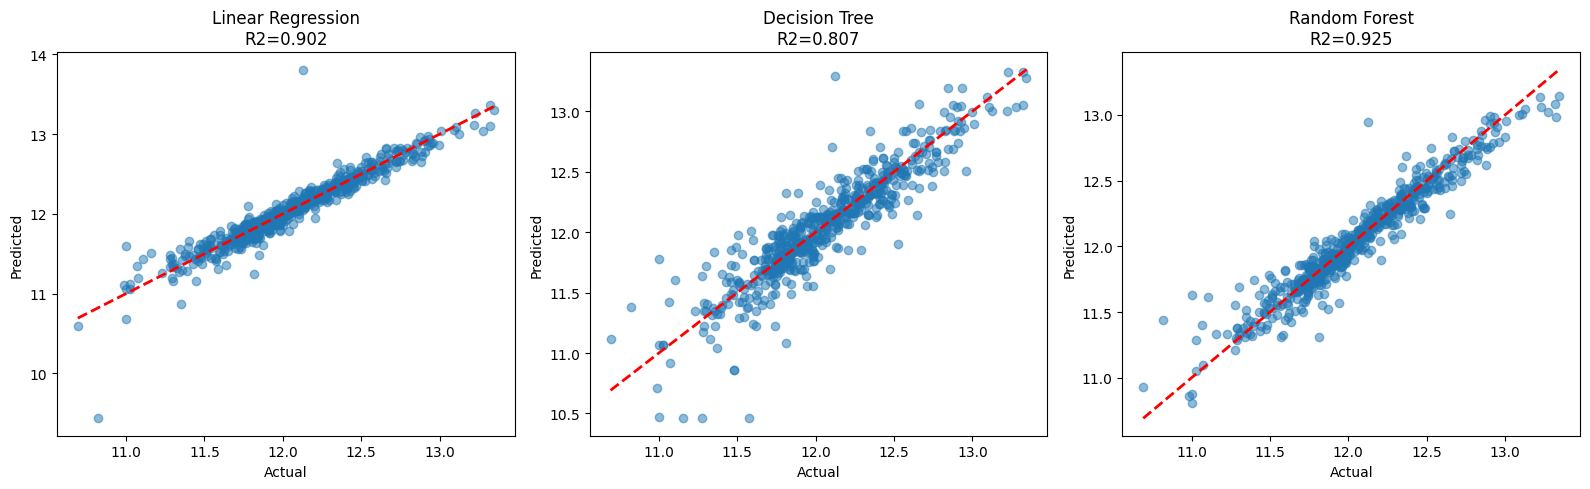

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models = {
    'Linear Regression': y_pred,
    'Decision Tree': y_pred_dt,
    'Random Forest': y_pred_rf
}

for ax, (name, preds) in zip(axes, models.items()):
    ax.scatter(y_test, preds, alpha=0.5)
    ax.plot([y_test.min(), y_test.max()], 
            [y_test.min(), y_test.max()], 
            'r--', lw=2)
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.set_title(f'{name}\nR2={r2_score(y_test, preds):.3f}')

plt.tight_layout()
plt.show()

### Clustring

- Total_SF المساحة الكلية.
- Total_Quality الجودة.
- House_Age العمر.
- Total_Bathrooms عدد الحمامات.
- Neighborhood المنطقة، بس دي اتحولت لـ columns كتير بعد الـ encoding.

In [29]:
cluster_features = [
    'Total_SF', 'Total_Quality', 'House_Age',
    'Total_Bathrooms', 'Total_Porch_SF', 'Has_Garage',
    'Has_Fireplace', 'Overall Qual', 'Gr Liv Area'
]

X_cluster = df_encoded[cluster_features].copy()
print(X_cluster.shape)
print(X_cluster.isnull().sum().sum())

(2930, 9)
0


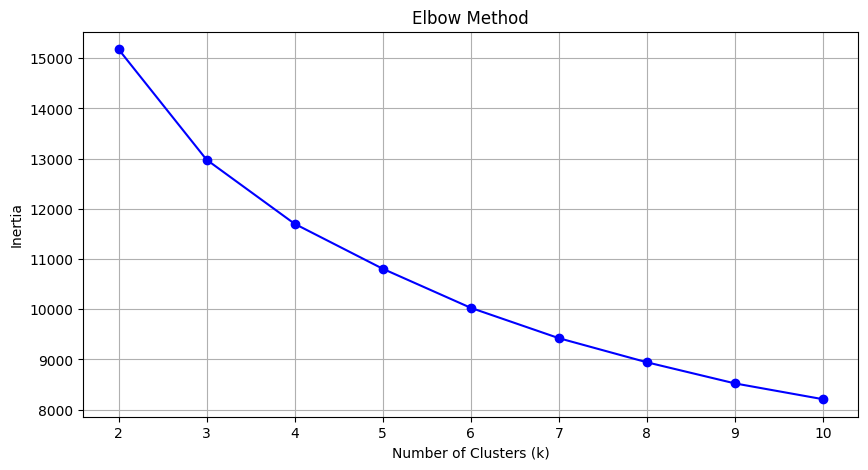

In [30]:
from sklearn.cluster import KMeans

inertias = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(k_range, inertias, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.xticks(k_range)
plt.grid(True)
plt.show()

In [31]:
from sklearn.metrics import silhouette_score

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_cluster)

silhouette = silhouette_score(X_cluster, clusters)
print(f"Silhouette Score: {silhouette:.4f}")

df_encoded['Cluster'] = clusters
print(df_encoded.groupby('Cluster')['SalePrice'].describe())

Silhouette Score: 0.1975
         count           mean           std       min       25%       50%  \
Cluster                                                                     
0        923.0  194155.037920  33998.159006   82500.0  172950.0  190000.0   
1        694.0  147507.952450  30873.057916   79000.0  128000.0  144300.0   
2        478.0  314704.510460  84720.650842  147000.0  260029.0  295746.5   
3        835.0  117039.617964  27775.603396   12789.0   99700.0  121000.0   

              75%       max  
Cluster                      
0        215000.0  392000.0  
1        160875.0  311500.0  
2        350000.0  755000.0  
3        136500.0  188000.0  


Silhouette Score: 0.1975
weak score !

In [32]:
print(df_encoded.groupby('Cluster')[['SalePrice', 'Total_SF', 
                                      'Total_Quality', 
                                      'House_Age']].mean().round(2))

         SalePrice  Total_SF  Total_Quality  House_Age
Cluster                                               
0        194155.04      0.16           0.16      -0.77
1        147507.95     -0.36           0.31       0.89
2        314704.51      1.52           0.98      -0.79
3        117039.62     -0.75          -1.00       0.56


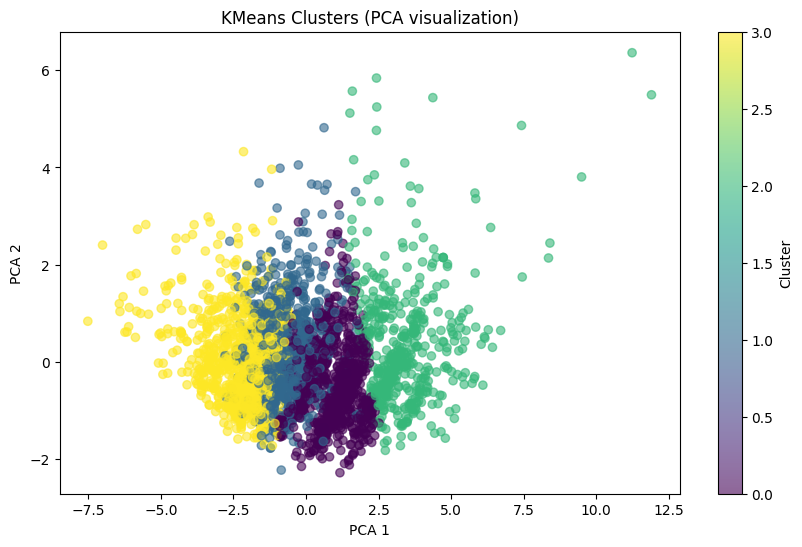

In [33]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], 
                      c=clusters, cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='Cluster')
plt.title('KMeans Clusters (PCA visualization)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.show()

In [34]:
from sklearn.cluster import DBSCAN
from sklearn.mixture import GaussianMixture

# DBSCAN
dbscan = DBSCAN(eps=1.5, min_samples=5)
dbscan_clusters = dbscan.fit_predict(X_cluster)
n_clusters_db = len(set(dbscan_clusters)) - (1 if -1 in dbscan_clusters else 0)
n_noise = list(dbscan_clusters).count(-1)
print(f"DBSCAN: {n_clusters_db} clusters, {n_noise} noise points")

# GMM
gmm = GaussianMixture(n_components=4, random_state=42)
gmm_clusters = gmm.fit_predict(X_cluster)
gmm_silhouette = silhouette_score(X_cluster, gmm_clusters)
print(f"GMM Silhouette: {gmm_silhouette:.4f}")
print(f"KMeans Silhouette: {silhouette:.4f}")

DBSCAN: 1 clusters, 110 noise points
GMM Silhouette: 0.0307
KMeans Silhouette: 0.1975


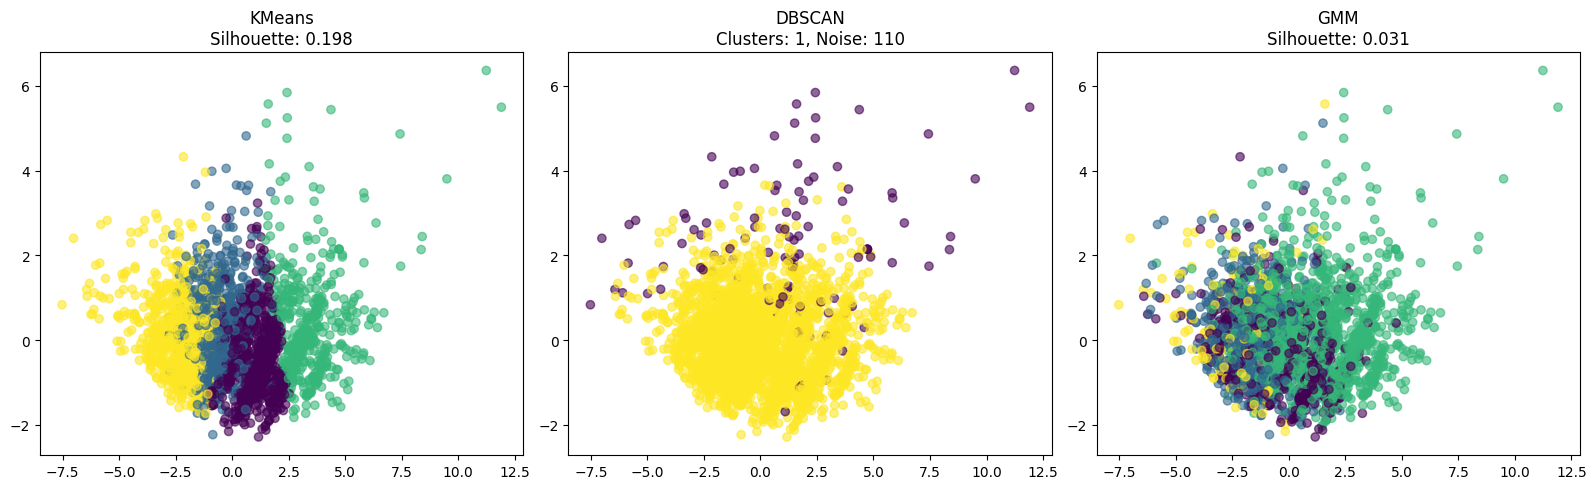

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# KMeans
X_pca = PCA(n_components=2).fit_transform(X_cluster)

axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', alpha=0.6)
axes[0].set_title(f'KMeans\nSilhouette: {silhouette:.3f}')

# DBSCAN
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_clusters, cmap='viridis', alpha=0.6)
axes[1].set_title(f'DBSCAN\nClusters: {n_clusters_db}, Noise: {n_noise}')

# GMM
axes[2].scatter(X_pca[:, 0], X_pca[:, 1], c=gmm_clusters, cmap='viridis', alpha=0.6)
axes[2].set_title(f'GMM\nSilhouette: {gmm_silhouette:.3f}')

plt.tight_layout()
plt.show()

shit!

### Classification

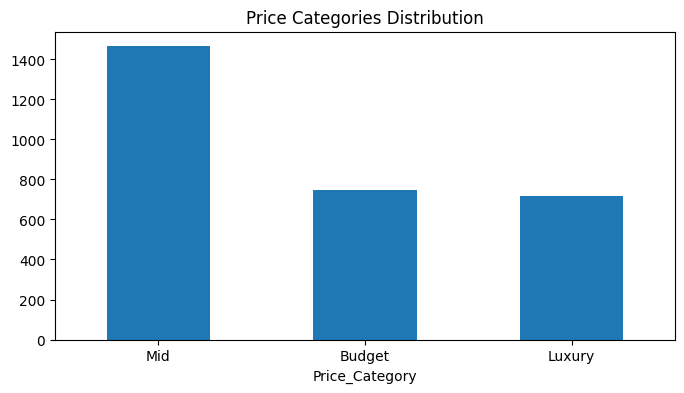

Price_Category
Mid       1465
Budget     746
Luxury     719
Name: count, dtype: int64


In [36]:
import numpy as np

def price_category(price):
    if price < 130000:
        return 'Budget'
    elif price < 215000:
        return 'Mid'
    else:
        return 'Luxury'

df_encoded['Price_Category'] = df_encoded['SalePrice'].apply(price_category)

df_encoded['Price_Category'].value_counts().plot(kind='bar', figsize=(8, 4))
plt.title('Price Categories Distribution')
plt.xticks(rotation=0)
plt.show()

print(df_encoded['Price_Category'].value_counts())

seems like there is near to balance in the data 

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Prepare data
X_clf = df_encoded.drop(columns=['SalePrice', 'Order', 'PID', 'Price_Category', 'Cluster'])
y_clf = df_encoded['Price_Category']

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42
)

# Train 3 models
models_clf = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

for name, model in models_clf.items():
    model.fit(X_train_clf, y_train_clf)
    y_pred_clf = model.predict(X_test_clf)
    print(f"\n{name}:")
    print(classification_report(y_test_clf, y_pred_clf))

/Users/mac/Amrbelal/nexus_ml_platform/nexus-ml/venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Logistic Regression:
              precision    recall  f1-score   support

      Budget       0.83      0.81      0.82       143
      Luxury       0.93      0.90      0.91       172
         Mid       0.84      0.87      0.86       271

    accuracy                           0.86       586
   macro avg       0.87      0.86      0.86       586
weighted avg       0.86      0.86      0.86       586


Decision Tree:
              precision    recall  f1-score   support

      Budget       0.74      0.75      0.74       143
      Luxury       0.84      0.84      0.84       172
         Mid       0.77      0.76      0.77       271

    accuracy                           0.78       586
   macro avg       0.78      0.78      0.78       586
weighted avg       0.78      0.78      0.78       586


Random Forest:
              precision    recall  f1-score   support

      Budget       0.87      0.82      0.84       143
      Luxury       0.93      0.87      0.90       172
         Mid       0.

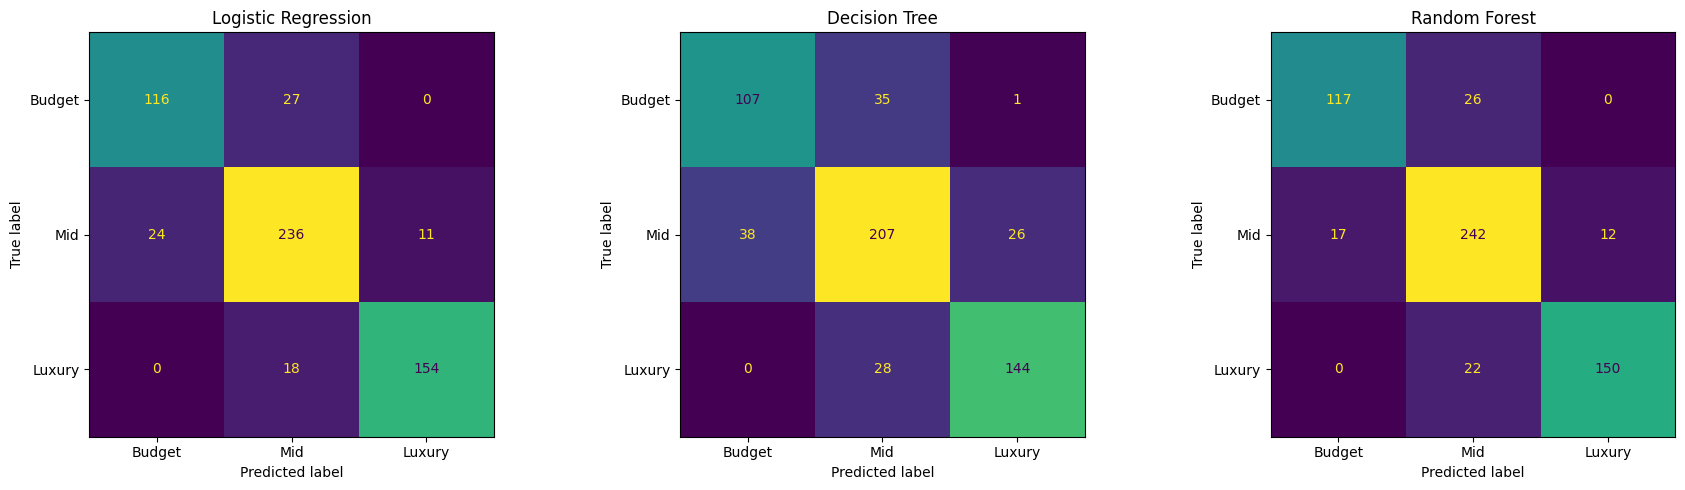

In [38]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, model) in zip(axes, models_clf.items()):
    y_pred_clf = model.predict(X_test_clf)
    cm = confusion_matrix(y_test_clf, y_pred_clf, labels=['Budget', 'Mid', 'Luxury'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Budget', 'Mid', 'Luxury'])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(f'{name}')

plt.tight_layout()
plt.show()

### Save Models 

In [40]:
import pickle
import os

os.makedirs('../models', exist_ok=True)

# Regression models
with open('../models/lr_regressor.pkl', 'wb') as f:
    pickle.dump(lr, f)

with open('../models/dt_regressor.pkl', 'wb') as f:
    pickle.dump(dt, f)

with open('../models/rf_regressor.pkl', 'wb') as f:
    pickle.dump(rf, f)

# Classification models
with open('../models/lr_classifier.pkl', 'wb') as f:
    pickle.dump(models_clf['Logistic Regression'], f)

with open('../models/dt_classifier.pkl', 'wb') as f:
    pickle.dump(models_clf['Decision Tree'], f)

with open('../models/rf_classifier.pkl', 'wb') as f:
    pickle.dump(models_clf['Random Forest'], f)

# Clustering models
with open('../models/kmeans.pkl', 'wb') as f:
    pickle.dump(kmeans, f)

with open('../models/dbscan.pkl', 'wb') as f:
    pickle.dump(dbscan, f)

with open('../models/gmm.pkl', 'wb') as f:
    pickle.dump(gmm, f)

# Preprocessing
with open('../models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('../models/feature_columns.pkl', 'wb') as f:
    pickle.dump(X_train.columns.tolist(), f)

print("All models saved!")

All models saved!


### MLFLOW

In [41]:
import mlflow 
import mlflow.sklearn

# where to save exps
mlflow.set_tracking_uri("sqlite:///../mlruns.db")
mlflow.set_experiment("nexusml-real-estate")

print("MLflow tracking URI:", mlflow.get_tracking_uri())
print("Experiment set!")

2026/05/03 22:44:21 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/03 22:44:21 INFO mlflow.store.db.utils: Updating database tables
INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
INFO  [alembic.runtime.migration] Will assume non-transactional DDL.
INFO  [alembic.runtime.migration] Running upgrade  -> 451aebb31d03, add metric step
INFO  [alembic.runtime.migration] Running upgrade 451aebb31d03 -> 90e64c465722, migrate user column to tags
INFO  [alembic.runtime.migration] Running upgrade 90e64c465722 -> 181f10493468, allow nulls for metric values
INFO  [alembic.runtime.migration] Running upgrade 181f10493468 -> df50e92ffc5e, Add Experiment Tags Table
INFO  [alembic.runtime.migration] Running upgrade df50e92ffc5e -> 7ac759974ad8, Update run tags with larger limit
INFO  [alembic.runtime.migration] Running upgrade 7ac759974ad8 -> 89d4b8295536, create latest metrics table
INFO  [89d4b8295536_create_latest_metrics_table_py] Migration complete!
INFO  

MLflow tracking URI: sqlite:///../mlruns.db
Experiment set!


In [42]:
# first exp 

with mlflow.start_run(run_name="random_forest_baseline"):
    # Log parameters
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("random_state", 42)
    mlflow.log_param("model_type", "RandomForestRegressor")
    
    # Log metrics
    mlflow.log_metric("rmse", 0.1175)
    mlflow.log_metric("r2", 0.9254)
    mlflow.log_metric("mae", mean_absolute_error(y_test, y_pred_rf))
    
    # Log model
    mlflow.sklearn.log_model(rf, "model")
    
    print("Run logged successfully!")

Run logged successfully!


Done with first exp now let's try with the rest 

In [43]:
models_to_log = {
    "linear_regression": (lr, y_pred, {"model_type": "LinearRegression"}),
    "decision_tree_regressor": (dt, y_pred_dt, {"model_type": "DecisionTreeRegressor", "max_depth": "None"}),
    "random_forest_regressor": (rf, y_pred_rf, {"model_type": "RandomForestRegressor", "n_estimators": 100}),
}

for run_name, (model, preds, params) in models_to_log.items():
    with mlflow.start_run(run_name=run_name):
        mlflow.log_params(params)
        mlflow.log_metric("rmse", np.sqrt(mean_squared_error(y_test, preds)))
        mlflow.log_metric("mae", mean_absolute_error(y_test, preds))
        mlflow.log_metric("r2", r2_score(y_test, preds))
        mlflow.sklearn.log_model(model, "model")
        print(f"Logged: {run_name}")

/Users/mac/Amrbelal/nexus_ml_platform/nexus-ml/venv/lib/python3.11/site-packages/_distutils_hack/__init__.py:18: UserWarning: Distutils was imported before Setuptools, but importing Setuptools also replaces the `distutils` module in `sys.modules`. This may lead to undesirable behaviors or errors. To avoid these issues, avoid using distutils directly, ensure that setuptools is installed in the traditional way (e.g. not an editable install), and/or make sure that setuptools is always imported before distutils.
  warnings.warn(
/Users/mac/Amrbelal/nexus_ml_platform/nexus-ml/venv/lib/python3.11/site-packages/_distutils_hack/__init__.py:33: UserWarning: Setuptools is replacing distutils.
  warnings.warn("Setuptools is replacing distutils.")


Logged: linear_regression


/Users/mac/Amrbelal/nexus_ml_platform/nexus-ml/venv/lib/python3.11/site-packages/_distutils_hack/__init__.py:18: UserWarning: Distutils was imported before Setuptools, but importing Setuptools also replaces the `distutils` module in `sys.modules`. This may lead to undesirable behaviors or errors. To avoid these issues, avoid using distutils directly, ensure that setuptools is installed in the traditional way (e.g. not an editable install), and/or make sure that setuptools is always imported before distutils.
  warnings.warn(
/Users/mac/Amrbelal/nexus_ml_platform/nexus-ml/venv/lib/python3.11/site-packages/_distutils_hack/__init__.py:33: UserWarning: Setuptools is replacing distutils.
  warnings.warn("Setuptools is replacing distutils.")


Logged: decision_tree_regressor
Logged: random_forest_regressor


/Users/mac/Amrbelal/nexus_ml_platform/nexus-ml/venv/lib/python3.11/site-packages/_distutils_hack/__init__.py:18: UserWarning: Distutils was imported before Setuptools, but importing Setuptools also replaces the `distutils` module in `sys.modules`. This may lead to undesirable behaviors or errors. To avoid these issues, avoid using distutils directly, ensure that setuptools is installed in the traditional way (e.g. not an editable install), and/or make sure that setuptools is always imported before distutils.
  warnings.warn(
/Users/mac/Amrbelal/nexus_ml_platform/nexus-ml/venv/lib/python3.11/site-packages/_distutils_hack/__init__.py:33: UserWarning: Setuptools is replacing distutils.
  warnings.warn("Setuptools is replacing distutils.")
